# MLE over time, v4 weak-measurement run (`data_mle_over_time_weak_2`)

Closed-system v4 (`multiparameter_trotter_v4_least_squares_over_time.py`, $J=3$, readout $J_y$, spin coherent
state along $x$) with the probe calibrated for weak measurement. The accumulated back-action

$$B(t)=\sum_{t_i\le t}\frac{\mathrm{Var}\,J_y(t_i)}{N_a\,\sigma^2}$$

is the projection noise the record has resolved, relative to the photon shot noise $\sigma^2$ per bin (the Sr note's
$\kappa N\!\int\!\mathrm{Var}\,dt$). The simulation's record model (unconditional mean plus white shot noise, no projection
noise or back-action) is self-consistent only for $B\ll1$. `--weak-target-time 14 --weak-threshold 0.1` fixes the photon
flux so that $B$ would reach $0.1$ at $T^*=14$ (the whole record) if the variance stayed at its initial value $J/2$. That gives
$\sigma=1.025$, 48 times the legacy 9.6e8-photon value (legacy runs reach $B=1$ after about 60 steps).

$\beta\in\{0,1,5,10,50\}$, 300 fits per ($\beta$, cutoff), 20 tasks (one $w_{\rm true}$ draw each). Every start is fit both
staged and directly on the full cutoff, and the lower cost is kept.

**What is compared.** One photon flux serves every $\beta$, so $\sigma$ cancels in any $\beta$-to-$\beta$ ratio of the plain bound
$\mathrm{tr}\,\mathbb{E}[F_i^{-1}]$. Twisting raises $\mathrm{Var}\,J_y$, so larger $\beta$ uses up the back-action budget sooner. The
**weak-budget bound** `fisher_inv_realavg_trace_weak_budget` $=\mathrm{tr}\,\mathbb{E}[F_i^{-1}]\cdot\bar B(T)/0.1$ is the reachable bound
if the flux were set separately for each $\beta$ and duration $T$ so that the mean $B$ equals $0.1$ at $T$. It does not depend on the
flux, and it charges each $\beta$ for the variance it creates.

**Excluded regions.** At the first cutoff ($t=0.01$), about 20 % of the per-realization Fisher matrices are singular, so
$\mathbb{E}[F_i^{-1}]$ is NaN there and that cutoff is not plotted. For $t\lesssim1$ the prior and the $\pm1$ fit box dominate
(most fits sit on the box at $t\approx0.4$), so the Monte Carlo variance falls below the bound for reasons that have nothing to do
with efficiency. That region is shaded gray.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

RUN = Path('data_mle_over_time_weak_2')
dt = 1e-3
D2_WRONG = 50.0   # err^T inv(E[F_i^-1]) err above this = wrong minimum (chi2 with 3 dof: tail ~ 1e-10)
T_SHOW = [2.16, 3.6, 7.18, 10.41, 14.0]
labels_omega = [r'$\omega_x$', r'$\omega_y$', r'$\omega_z$']
# Categorical slots in fixed order (validated: adjacent CVD dE >= 9); the per-beta marker is the secondary encoding
beta_colors = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']
beta_markers = ['o', 's', '^', 'D', 'v']
plt.rcParams.update({'axes.grid': True, 'grid.color': '#dcdcd8', 'grid.linewidth': 0.6,
                     'lines.linewidth': 1.6, 'lines.markersize': 4.5, 'legend.fontsize': 8})

def load_npy(root_folder):
    return {file.stem: np.load(file) for file in Path(root_folder).rglob('*.npy')}

def task_dirs(root):
    return sorted((p for p in Path(root).iterdir() if p.is_dir() and p.name.startswith('task_')),
                  key=lambda p: int(p.name.split('_')[1]))

def safe_inv(m):
    '''Batched inverse, NaN wherever the input is non-finite (singular per-realization Fisher at the first cutoff).'''
    ok = np.isfinite(m).all(axis=(-2, -1))
    inv = np.linalg.inv(np.where(ok[..., None, None], m, np.eye(m.shape[-1])))
    return np.where(ok[..., None, None], inv, np.nan)

def tr_cov(err, keep):
    '''Trace of the sample covariance of err (..., n_fits, 3) over the fits with keep True; NaN with fewer than 4 survivors.'''
    out = np.full(err.shape[:-2], np.nan)
    for idx in np.ndindex(*out.shape):
        e = err[idx][keep[idx]]
        if len(e) > 3:
            out[idx] = np.trace(np.cov(e, rowvar=False))
    return out

def aggregate(root):
    '''Stack all tasks of one run on a leading task axis; per-(task, beta, cutoff) statistics under three fit filters.'''
    tasks = task_dirs(root)
    runs = [load_npy(p) for p in tasks]
    ref = runs[0]
    for r in runs:
        assert np.array_equal(r['beta_array'], ref['beta_array']) and np.array_equal(r['time_cutoffs_array'], ref['time_cutoffs_array'])
        assert np.isclose(r['sn_sd'], ref['sn_sd'])
    S = lambda k: np.concatenate([r[k] for r in runs], axis=0)   # per-trial arrays carry a leading trial axis of 1
    probe = json.load(open(tasks[0] / 'probe_parameters.json'))
    tc, sn = ref['time_cutoffs_array'], float(ref['sn_sd'])
    n_sub = np.array([np.sum(ref['measurement_indices'] <= c) for c in tc])   # cost band from this run's own sn_sd
    floor, sigma = 0.5 * sn**2 * n_sub, 0.5 * sn**2 * np.sqrt(2 * n_sub)
    w_true, w_all, cost = S('w_true'), S('w_est_all'), S('cost_est_all')
    err = w_all - w_true[:, None, None, None, :]
    bound_ra = S('fisher_inv_realavg')
    d2 = np.einsum('abtki,abtij,abtkj->abtk', err, safe_inv(bound_ra), err)
    in_band = cost <= (floor + 5 * sigma)[None, None, :, None]
    wrong = d2 > D2_WRONG
    B = S('backaction')
    return dict(
        name=Path(root).name, n_tasks=len(tasks), probe=probe, sn=sn, thr=probe['weak_threshold'],
        beta=ref['beta_array'], times=tc * dt, w_true=w_true,
        B=B, B_mean=B.mean(axis=-1), crossing=S('crossing_times'), accept=S('accept_fraction'),
        bound=np.trace(bound_ra, axis1=-2, axis2=-1), bound_naive=S('fisher_inv_trace'),
        bound_wb=S('fisher_inv_realavg_trace_weak_budget'),
        tr_all=tr_cov(err, np.ones_like(wrong)), tr_band=tr_cov(err, in_band), tr_right=tr_cov(err, ~wrong),
        wrong_frac=wrong.mean(axis=-1), wrong_out_band_frac=(wrong & ~in_band).mean(axis=-1),
        box_frac=(np.abs(w_all) > 0.999).any(axis=-1).mean(axis=-1))

def time_to_target(curve, times, target):
    '''Earliest time after which curve stays below target (log-interpolated); NaN if never within the run.'''
    above = curve > target
    if not above.any():
        return times[0]
    i = int(np.max(np.where(above)[0]))
    if i + 1 >= len(times):
        return np.nan
    f = (np.log(curve[i]) - np.log(target)) / (np.log(curve[i]) - np.log(curve[i + 1]))
    return times[i] + f * (times[i + 1] - times[i])

def tmean(x):
    '''Mean over the task axis, ignoring NaN.'''
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=RuntimeWarning)
        return np.nanmean(x, axis=0)

def style_time_axis(ax):
    ax.axvspan(0, 1, color='#efefec', zorder=0, lw=0)
    ax.set_xlabel(r'Time ($\Omega$t)')

def beta_line(ax, x, y, b_idx, **kw):
    ax.plot(x, y, color=beta_colors[b_idx], marker=beta_markers[b_idx], label=fr'$\beta={betas[b_idx]:g}$', **kw)

R = aggregate(RUN)
betas, times, thr = R['beta'], R['times'], R['thr']
show = slice(1, None)   # drop the first cutoff (t = 0.01): singular per-realization Fisher, NaN bound
j_show = [int(np.argmin(np.abs(times - t))) for t in T_SHOW]
t_cols = [f't = {times[j]:.2f}' for j in j_show]
print(f"{R['name']}: {R['n_tasks']} tasks, beta = {betas}, sigma = {R['sn']:.4f}, weak_threshold = {thr}, "
      f"T* = {R['probe']['weak_target_time']}, photons per bin = {R['probe']['photons_per_bin']:.1f}")

data_mle_over_time_weak_2: 20 tasks, beta = [ 0.  1.  5. 10. 50.], sigma = 1.0247, weak_threshold = 0.1, T* = 14.0, photons per bin = 30.1


## Back-action budget: how weak is the record?

Mean $B$ over realizations and tasks, and the fraction of realizations still below the threshold. The calibration assumes
the initial variance $J/2=1.5$. Without twisting the variance of a coherent state is $\tfrac{J}{2}(1-m_y^2)\le J/2$, so $\beta=0$
stays below the threshold. Twisting pushes the variance toward $J(J+1)/3=4$, so $\beta\ge5$ crosses $0.1$ around $t\approx5$–$6$.
No realization reaches $B=1$.

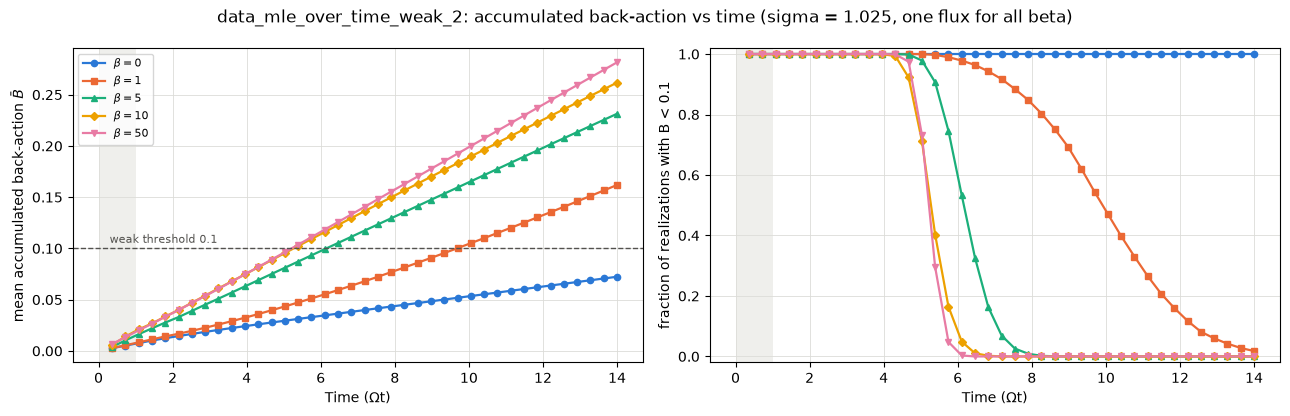

,mean B at T = 14,mean B / threshold,fraction crossing 0.1,median crossing time,fraction crossing 1
β = 0,0.0724,0.724,0,—,0
β = 1,0.162,1.62,0.982,9.87,0
β = 5,0.231,2.31,1,6.16,0
β = 10,0.262,2.62,1,5.28,0
β = 50,0.282,2.82,1,5.22,0


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for b in range(len(betas)):
    beta_line(axes[0], times[show], tmean(R['B_mean'])[b, show], b)
    beta_line(axes[1], times[show], tmean((R['B'] < thr).mean(axis=-1))[b, show], b)
axes[0].axhline(thr, color='#52514e', ls='--', lw=1)
axes[0].annotate(f'weak threshold {thr:g}', (0.3, thr), xytext=(0, 4), textcoords='offset points', fontsize=8, color='#52514e')
axes[0].set_ylabel(r'mean accumulated back-action $\bar B$')
axes[1].set_ylabel(f'fraction of realizations with B < {thr:g}')
axes[1].set_ylim(-0.02, 1.02)
for ax in axes:
    style_time_axis(ax)
axes[0].legend(loc='upper left')
fig.suptitle(f"{R['name']}: accumulated back-action vs time (sigma = {R['sn']:.3f}, one flux for all beta)")
plt.tight_layout(); plt.show()

rows = {}
for b, beta in enumerate(betas):
    c = R['crossing'][:, b]                     # (task, realization, level)
    hit = np.isfinite(c[..., 0])
    rows[f'β = {beta:g}'] = {
        'mean B at T = 14': tmean(R['B_mean'])[b, -1],
        'mean B / threshold': tmean(R['B_mean'])[b, -1] / thr,
        'fraction crossing 0.1': hit.mean(),
        'median crossing time': np.median(c[..., 0][hit]) if hit.any() else np.nan,
        'fraction crossing 1': np.isfinite(c[..., 1]).mean(),
    }
display(pd.DataFrame(rows).T.style.format('{:.3g}', na_rep='—').set_caption('Back-action summary (20 tasks x 300 realizations per beta)'))

## Fits: wrong minima and efficiency

A fit is counted as a **wrong minimum** when $e^{\mathsf T}\,\mathbb{E}[F_i^{-1}]^{-1}e>50$, with $e=\hat w-w_{\rm true}$. For an estimator in the
right minimum this has a $\chi^2_3$ tail of about $10^{-10}$. Measuring against the realization-averaged bound makes the test
conservative: a realization whose own control is poorly conditioned can still produce a large error legitimately.

The efficiency panels show task-averaged tr Cov over task-averaged $\mathrm{tr}\,\mathbb{E}[F_i^{-1}]$ under three filters: none, the usual
$5\sigma$ cost band (as in the v5–v7 notebooks), and wrong minima removed. The right panel of the second figure shows that the wrong
minima concentrate in the tasks with the largest $|w_{\rm true}|$.

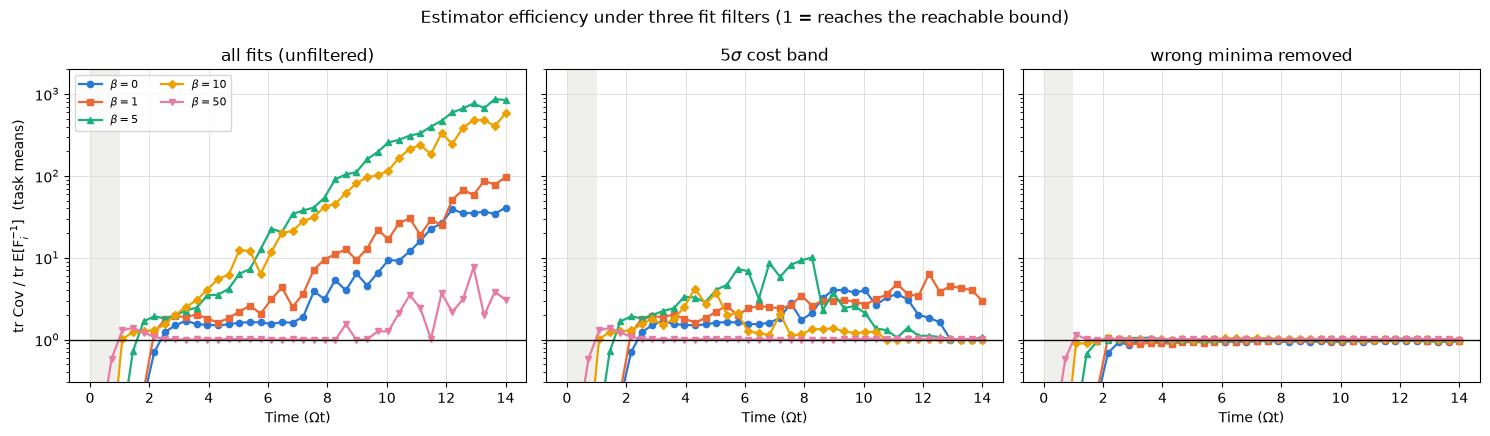

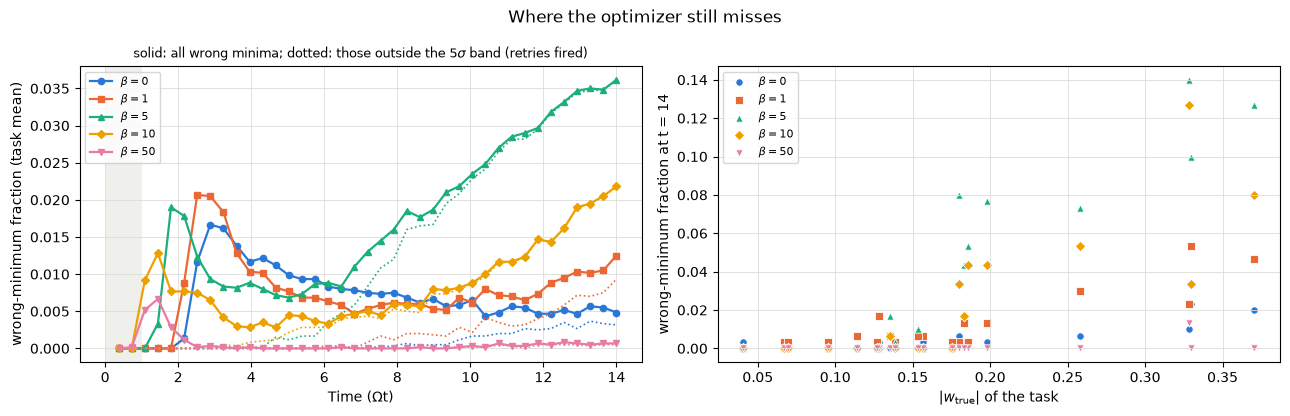

,t = 2.16,t = 3.60,t = 7.18,t = 10.41,t = 14.00
β = 0,1.000,1.000,1.000,0.998,0.997
β = 1,1.000,1.000,0.999,0.996,0.991
β = 5,1.000,1.000,0.992,0.976,0.964
β = 10,1.000,1.000,0.996,0.990,0.978
β = 50,1.000,1.000,1.000,1.000,1.000


In [3]:
filters = [('tr_all', 'all fits (unfiltered)'), ('tr_band', r'5$\sigma$ cost band'), ('tr_right', 'wrong minima removed')]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharey=True)
for ax, (key, title) in zip(axes, filters):
    for b in range(len(betas)):
        beta_line(ax, times[show], (tmean(R[key]) / tmean(R['bound']))[b, show], b)
    ax.axhline(1, color='#0b0b0b', lw=1)
    ax.set_yscale('log'); ax.set_ylim(0.3, 2e3); ax.set_title(title); style_time_axis(ax)
axes[0].set_ylabel(r'tr Cov / tr E[F$_i^{-1}$]  (task means)')
axes[0].legend(loc='upper left', ncol=2)
fig.suptitle('Estimator efficiency under three fit filters (1 = reaches the reachable bound)')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for b in range(len(betas)):
    beta_line(axes[0], times[show], tmean(R['wrong_frac'])[b, show], b)
    axes[0].plot(times[show], tmean(R['wrong_out_band_frac'])[b, show], color=beta_colors[b], ls=':', lw=1.2)
    axes[1].scatter(np.linalg.norm(R['w_true'], axis=1), R['wrong_frac'][:, b, -1], color=beta_colors[b],
                    marker=beta_markers[b], s=28, label=fr'$\beta={betas[b]:g}$', edgecolors='white', linewidths=0.6)
axes[0].set_ylabel('wrong-minimum fraction (task mean)'); style_time_axis(axes[0])
axes[0].set_title('solid: all wrong minima; dotted: those outside the 5$\\sigma$ band (retries fired)', fontsize=9)
axes[1].set_xlabel(r'$|w_{\rm true}|$ of the task'); axes[1].set_ylabel(f'wrong-minimum fraction at t = {times[-1]:.0f}')
axes[0].legend(loc='upper left'); axes[1].legend(loc='upper left')
fig.suptitle('Where the optimizer still misses')
plt.tight_layout(); plt.show()

def ratio_table(key, how):
    f = np.nanmedian if how == 'median' else np.nanmean
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=RuntimeWarning)
        r = f(R[key] / R['bound'], axis=0)
    return pd.DataFrame(r[:, j_show], index=[f'β = {b:g}' for b in betas], columns=t_cols)
for key, title in filters:
    df = pd.concat({'task median': ratio_table(key, 'median'), 'task mean': ratio_table(key, 'mean')}, axis=1)
    display(df.style.format('{:.2f}').set_caption(f'tr Cov / tr E[F_i^-1] per task, {title}'))
acc = pd.DataFrame(tmean(R['accept'])[:, j_show], index=[f'β = {b:g}' for b in betas], columns=t_cols)
display(acc.style.format('{:.3f}').set_caption('accept_fraction: share of fits inside the 5σ cost band (task mean)'))

## Variance against both bounds

Solid: total variance after the $5\sigma$ cost band (the usual pipeline). Dashed: reachable bound $\mathrm{tr}\,\mathbb{E}[F_i^{-1}]$. Dotted: naive
bound $\mathrm{tr}\,[\mathbb{E}F]^{-1}$. All three are task means.

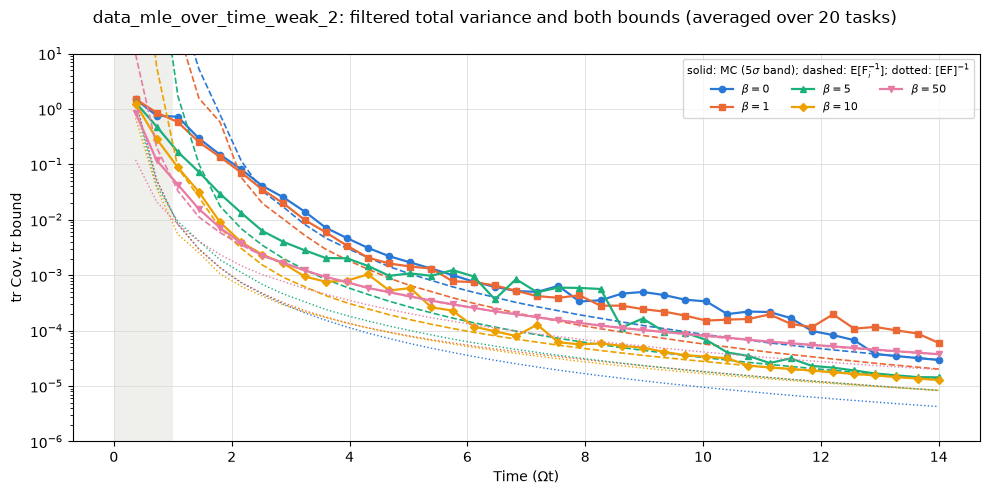

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
for b in range(len(betas)):
    beta_line(ax, times[show], tmean(R['tr_band'])[b, show], b)
    ax.plot(times[show], tmean(R['bound'])[b, show], color=beta_colors[b], ls='--', lw=1.2)
    ax.plot(times[show], tmean(R['bound_naive'])[b, show], color=beta_colors[b], ls=':', lw=1.0)
ax.set_yscale('log'); ax.set_ylim(1e-6, 1e1); style_time_axis(ax)
ax.set_ylabel('tr Cov, tr bound')
ax.legend(loc='upper right', ncol=3, title=r'solid: MC (5$\sigma$ band); dashed: E[F$_i^{-1}$]; dotted: [EF]$^{-1}$', title_fontsize=8)
fig.suptitle(f"{R['name']}: filtered total variance and both bounds (averaged over {R['n_tasks']} tasks)")
plt.tight_layout(); plt.show()

## Which $\beta$ under a fixed back-action budget?

Left: the reachable bound at the common flux the run used. Right: the same bound with the flux rescaled for each $\beta$ and $T$
so that the mean $B$ equals the threshold at $T$. Only the right panel charges twisting for the extra variance it creates. The ratio
plot divides each $\beta$ by $\beta=0$ (below 1 means twisting helps). Solid lines are the weak-budget bound, dashed lines the common flux.

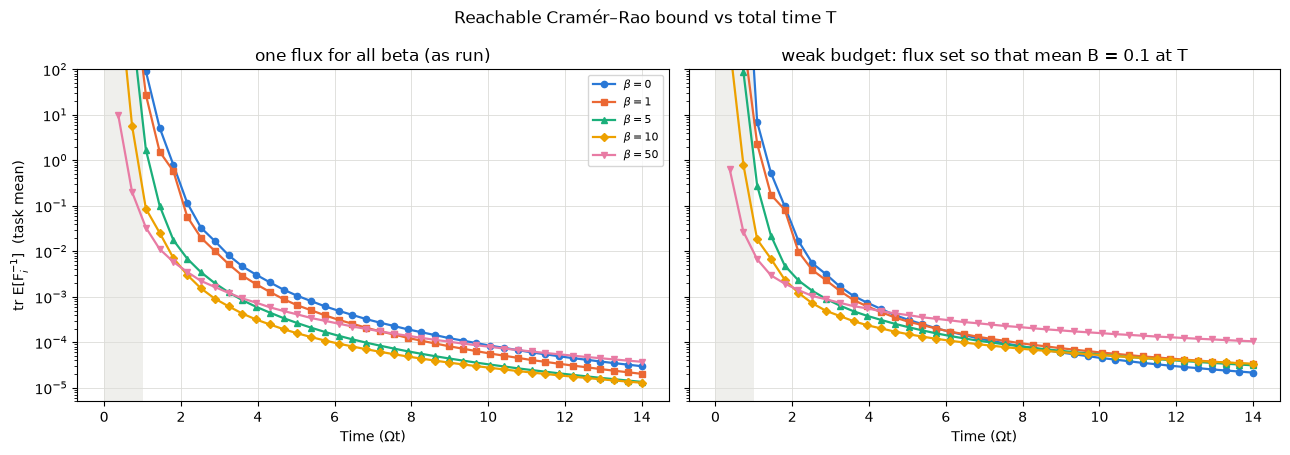

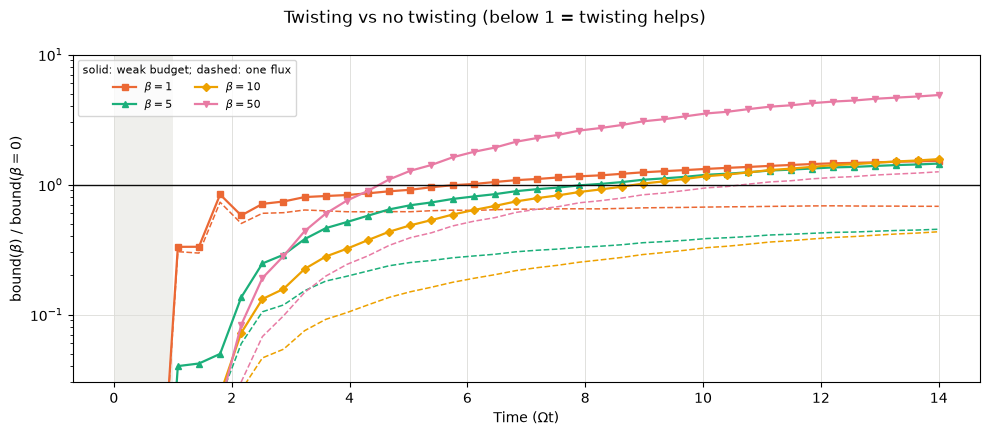

,t = 2.16,t = 3.60,t = 7.18,t = 10.41,t = 14.00
one flux,10,10,10,10,10
weak budget,10,10,10,0,0


target,1e-02,1e-03,1e-04,3e-05
β = 0,2.33,3.64,7.39,11.95
β = 1,2.16,3.47,7.78,—
β = 5,1.63,2.79,7.15,—
β = 10,1.31,2.30,6.43,—
β = 50,0.98,2.61,—,—


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, key, title in [(axes[0], 'bound', 'one flux for all beta (as run)'),
                       (axes[1], 'bound_wb', f'weak budget: flux set so that mean B = {thr:g} at T')]:
    for b in range(len(betas)):
        beta_line(ax, times[show], tmean(R[key])[b, show], b)
    ax.set_yscale('log'); ax.set_ylim(5e-6, 1e2); ax.set_title(title); style_time_axis(ax)
axes[0].set_ylabel(r'tr E[F$_i^{-1}$]  (task mean)'); axes[0].legend(loc='upper right')
fig.suptitle('Reachable Cramér–Rao bound vs total time T')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10, 4.4))
for b in range(1, len(betas)):
    beta_line(ax, times[show], (tmean(R['bound_wb'])[b] / tmean(R['bound_wb'])[0])[show], b)
    ax.plot(times[show], (tmean(R['bound'])[b] / tmean(R['bound'])[0])[show], color=beta_colors[b], ls='--', lw=1.1)
ax.axhline(1, color='#0b0b0b', lw=1)
ax.set_yscale('log'); ax.set_ylim(0.03, 10); style_time_axis(ax); ax.set_ylabel(r'bound($\beta$) / bound($\beta=0$)')
ax.legend(loc='upper left', ncol=2, title='solid: weak budget; dashed: one flux', title_fontsize=8)
fig.suptitle('Twisting vs no twisting (below 1 = twisting helps)')
plt.tight_layout(); plt.show()

best = pd.DataFrame({'one flux': [betas[np.nanargmin(tmean(R['bound'])[:, j])] for j in j_show],
                     'weak budget': [betas[np.nanargmin(tmean(R['bound_wb'])[:, j])] for j in j_show]},
                    index=t_cols).T
display(best.style.format('{:g}').set_caption('Best beta by the reachable bound'))

targets = [1e-2, 1e-3, 1e-4, 3e-5]
ttt = pd.DataFrame({f'β = {b:g}': [time_to_target(tmean(R['bound_wb'])[i, show], times[show], tgt) for tgt in targets]
                    for i, b in enumerate(betas)}, index=[f'{t:.0e}' for t in targets]).T
ttt.columns.name = 'target'
display(ttt.style.format(lambda v: '—' if np.isnan(v) else f'{v:.2f}').highlight_min(axis=0, props='font-weight:bold;')
        .set_caption('Weak budget: time (Ω t) after which tr E[F_i^-1] stays below the target (bold = fastest β, — = not within T = 14)'))

## Findings

1. **The record stays weak, but twisting uses up the budget.** At $T=14$ the mean $B$ is 0.072 for $\beta=0$ (0.72 of the target,
   since the coherent-state variance never exceeds its initial value) and 0.16–0.28 for $\beta=1$–50. Every realization with
   $\beta\ge5$ crosses 0.1 at $t\approx5$–6, and $\beta=1$ crosses at $t\approx10$. No realization reaches $B=1$, so the unmodelled
   projection-noise and back-action corrections stay below about 30 % everywhere.
2. **Fits in the right minimum reach the bound.** With wrong minima removed, tr Cov / tr $\mathbb{E}[F_i^{-1}]$ is 0.95–1.05 for every $\beta$
   from $t\approx2$ on.
3. **The remaining wrong minima still dominate the unfiltered covariance at late times.** They are at most 3.6 % of the fits
   ($\beta=5$, $T=14$), yet at $T=14$ they inflate the task-mean ratio to 3–850 for every $\beta$, and the task median to 7.5 ($\beta=1$) and
   12 ($\beta=5$). They concentrate in the tasks with $|w_{\rm true}|\gtrsim0.18$.
   - For $\beta\ge5$, most wrong minima lie outside the $5\sigma$ band: the retries ran, and two random starts were not enough.
   - For $\beta=0$ and 1, most lie inside the band, so no retry ran. After the band filter, $\beta=1$ is still at 1.6× (median) and 3.0×
     (mean) the bound at $T=14$.
4. **At one common flux, $\beta=10$ is best at every $t\ge2$.** At $T=14$ its bound is 2.3 times lower than $\beta=0$'s.
5. **Under a fixed back-action budget, twisting buys speed, not final precision.**
   - $\beta=10$ stays best up to $T\approx7$: 14 times lower than $\beta=0$ at $T=2.2$, 3.6 times at 3.6, 1.3 times at 7.2.
   - From $T\approx10$, $\beta=0$ is best. At $T=14$ its bound is $2.2\times10^{-5}$, against $3.1$–$3.4\times10^{-5}$ for $\beta=1$–10 and
     $1.1\times10^{-4}$ for $\beta=50$.
   - Time to reach $10^{-3}$: 2.3 ($\beta=10$) vs 3.6 ($\beta=0$). Time to reach $10^{-4}$: 6.4 vs 7.4. Only $\beta=0$ reaches $3\times10^{-5}$
     within $T=14$.
   - The extra variance twisting creates (2.3–2.8 times more back-action at $T=14$) eventually costs more information than the
     twisting adds.